# A/B 테스트 분석: 랜딩 페이지 디자인 실험

**실험 설계**: 대조군(control) = 기존 랜딩 페이지, 실험군(treatment) = 새로운 디자인  
**데이터**: `resources/ab_test_results.csv`  
**목표**: 새 디자인이 전환율 및 매출에 유의미한 차이를 만드는지 검증

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, norm, shapiro
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 출력 경로
OUTPUT_DIR = r'..\output'
DATA_PATH = r'..\resources\ab_test_results.csv'

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 기본 탐색

In [2]:
df = pd.read_csv(DATA_PATH)
df['signup_date'] = pd.to_datetime(df['signup_date'])

print(f'총 레코드: {len(df):,}개')
print(f'컬럼: {list(df.columns)}')
print()
print(df.head())
print()
print(df.dtypes)
print()
print('결측값:')
print(df.isnull().sum())

총 레코드: 500개
컬럼: ['user_id', 'group', 'converted', 'revenue', 'session_duration_seconds', 'pages_viewed', 'device', 'signup_date']

  user_id      group  converted  revenue  session_duration_seconds  \
0    U001    control          0      0.0                       245   
1    U002  treatment          1     45.5                       380   
2    U003    control          1     32.0                       520   
3    U004  treatment          0      0.0                       190   
4    U005    control          0      0.0                       210   

   pages_viewed   device signup_date  
0             8  desktop  2025-11-15  
1            12   mobile  2025-11-15  
2            15  desktop  2025-11-15  
3             6   tablet  2025-11-15  
4             7   mobile  2025-11-15  

user_id                                str
group                                  str
converted                            int64
revenue                            float64
session_duration_seconds             int6

In [3]:
# 그룹별 기본 통계
print('=== 그룹별 기본 통계 ===')
print(df.groupby('group').agg(
    사용자수=('user_id', 'count'),
    전환수=('converted', 'sum'),
    전환율=('converted', 'mean'),
    평균매출=('revenue', 'mean'),
    총매출=('revenue', 'sum')
).round(4))

=== 그룹별 기본 통계 ===
           사용자수  전환수    전환율    평균매출       총매출
group                                        
control     250  123  0.492  19.170   4792.50
treatment   250  198  0.792  50.893  12723.25


## 2. SRM(Sample Ratio Mismatch) 검사 — 테스트 설계 검증

In [4]:
# 두 그룹의 크기가 균형 잡혀 있는지 카이제곱 검정으로 확인
group_counts = df['group'].value_counts()
n_control = group_counts.get('control', 0)
n_treatment = group_counts.get('treatment', 0)
n_total = n_control + n_treatment

print(f'대조군: {n_control:,}명')
print(f'실험군: {n_treatment:,}명')
print(f'비율: {n_control/n_total:.3f} vs {n_treatment/n_total:.3f}')
print()

# 50:50 기대값으로 카이제곱 검정
expected = n_total / 2
chi2_srm, p_srm = stats.chisquare([n_control, n_treatment])

print(f'SRM 카이제곱 통계량: {chi2_srm:.4f}')
print(f'p값: {p_srm:.4f}')

if p_srm < 0.05:
    print('⚠️  경고: SRM 의심 — 그룹 크기가 유의미하게 불균형합니다!')
else:
    print('✅ SRM 없음 — 그룹 크기가 균형 잡혀 있습니다.')

대조군: 250명
실험군: 250명
비율: 0.500 vs 0.500

SRM 카이제곱 통계량: 0.0000
p값: 1.0000
✅ SRM 없음 — 그룹 크기가 균형 잡혀 있습니다.


In [5]:
# 디바이스별, 날짜별 그룹 분포 확인 (추가 SRM 검사)
print('=== 디바이스별 그룹 분포 ===')
device_group = pd.crosstab(df['device'], df['group'])
print(device_group)
print()

# 날짜별 배정 균형
print('=== 날짜별 그룹 배정 ===')
date_group = pd.crosstab(df['signup_date'].dt.date, df['group'])
print(date_group)

=== 디바이스별 그룹 분포 ===
group    control  treatment
device                     
desktop      103         87
mobile       101        137
tablet        46         26

=== 날짜별 그룹 배정 ===
group        control  treatment
signup_date                    
2025-11-15         3          3
2025-11-16         3          3
2025-11-17         3          3
2025-11-18         2          2
2025-11-19         3          2
...              ...        ...
2026-03-13         2          2
2026-03-14         2          2
2026-03-15         2          2
2026-03-16         2          2
2026-03-17         2          2

[123 rows x 2 columns]


## 3. 통계 검정 가정(Assumptions) 검토

In [6]:
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# 전환율은 이진값 → 카이제곱 또는 z-검정 적합
# 매출은 비정규 분포 의심 (0 값 다수) → 정규성 검정

print('=== 매출 정규성 검정 (Shapiro-Wilk) ===')
# 표본이 크면 Shapiro-Wilk는 너무 민감 → 전환자만 또는 QQ플롯 함께 사용
rev_control = control['revenue']
rev_treatment = treatment['revenue']

# 전체 매출 (0 포함)
if len(rev_control) <= 5000:
    stat_c, p_c = shapiro(rev_control)
    stat_t, p_t = shapiro(rev_treatment)
    print(f'대조군 (0 포함): W={stat_c:.4f}, p={p_c:.6f}')
    print(f'실험군 (0 포함): W={stat_t:.4f}, p={p_t:.6f}')
else:
    print('표본 크기 > 5000: Shapiro-Wilk 생략, 시각적 검토 및 비모수 검정 사용')

print()
print('=== 매출 기술통계 ===')
print(df.groupby('group')['revenue'].describe().round(2))

# 0값 비중 확인
print()
print('=== 매출 0인 비율 (미전환) ===')
print(df.groupby('group').apply(lambda x: (x['revenue'] == 0).mean()).round(4))

=== 매출 정규성 검정 (Shapiro-Wilk) ===
대조군 (0 포함): W=0.7206, p=0.000000
실험군 (0 포함): W=0.7267, p=0.000000

=== 매출 기술통계 ===
           count   mean    std  min    25%   50%    75%   max
group                                                        
control    250.0  19.17  19.75  0.0   0.00   0.0  39.00  46.5
treatment  250.0  50.89  27.04  0.0  52.31  61.0  68.94  82.0

=== 매출 0인 비율 (미전환) ===
group
control      0.508
treatment    0.208
dtype: float64


In [7]:
# 독립성 가정: 사용자당 1회 배정인지 확인
dup_check = df['user_id'].duplicated().sum()
print(f'중복 user_id 수: {dup_check}')
if dup_check == 0:
    print('✅ 각 사용자는 한 그룹에만 배정됨 (독립성 만족)')
else:
    print('⚠️  중복 사용자 발견 — 독립성 가정 위반 가능')

# 교차 그룹 오염 확인
cross = df.groupby('user_id')['group'].nunique()
contaminated = (cross > 1).sum()
print(f'두 그룹 동시 배정된 사용자: {contaminated}')

중복 user_id 수: 0
✅ 각 사용자는 한 그룹에만 배정됨 (독립성 만족)
두 그룹 동시 배정된 사용자: 0


## 4. 검정력(Power) 분석 — MDE 및 필요 표본 크기 계산

In [8]:
from math import ceil

# 기준 전환율
p_base = control['converted'].mean()
alpha = 0.05   # 유의수준
power = 0.80   # 목표 검정력

# 검정력 공식으로 필요 표본 크기 계산 (단측이 아닌 양측)
z_alpha = norm.ppf(1 - alpha / 2)  # 1.96
z_beta  = norm.ppf(power)          # 0.84

print(f'대조군 기준 전환율: {p_base:.4f} ({p_base*100:.2f}%)')
print()

# MDE별 필요 표본 크기 계산
mde_list = [0.01, 0.02, 0.03, 0.05, 0.10]
print(f'{'MDE':>8} {'p_treatment':>14} {'그룹당 필요 n':>16} {'현재 n으로 검출 가능':>22}')
print('-' * 65)
for mde in mde_list:
    p_t = p_base + mde
    p_bar = (p_base + p_t) / 2
    n_required = ceil(
        (z_alpha * (2 * p_bar * (1 - p_bar)) ** 0.5 +
         z_beta  * (p_base * (1 - p_base) + p_t * (1 - p_t)) ** 0.5) ** 2 /
        (mde ** 2)
    )
    detectable = '✅' if n_control >= n_required else '❌'
    print(f'{mde*100:>7.1f}% {p_t:>14.4f} {n_required:>16,} {detectable:>22}')

# 실제 검정력 계산 (현재 표본으로 관측된 효과를 탐지할 수 있는가)
p_obs_treatment = treatment['converted'].mean()
obs_mde = p_obs_treatment - p_base
print()
print(f'관측된 전환율 차이 (MDE): {obs_mde*100:.2f}%p')

대조군 기준 전환율: 0.4920 (49.20%)

     MDE    p_treatment         그룹당 필요 n           현재 n으로 검출 가능
-----------------------------------------------------------------
    1.0%         0.5020           39,242                      ❌
    2.0%         0.5120            9,810                      ❌
    3.0%         0.5220            4,359                      ❌
    5.0%         0.5420            1,567                      ❌
   10.0%         0.5920              389                      ❌

관측된 전환율 차이 (MDE): 30.00%p


## 5. 전환율 통계 검정 (카이제곱 + z-검정)

In [9]:
# 분할표 구성
n_conv_control   = control['converted'].sum()
n_noconv_control = n_control - n_conv_control
n_conv_treatment   = treatment['converted'].sum()
n_noconv_treatment = n_treatment - n_conv_treatment

contingency = np.array([[n_conv_control,   n_noconv_control],
                         [n_conv_treatment, n_noconv_treatment]])

p_c = n_conv_control   / n_control
p_t = n_conv_treatment / n_treatment

print(f'대조군 전환율:   {p_c:.4f} ({n_conv_control}/{n_control})')
print(f'실험군 전환율:   {p_t:.4f} ({n_conv_treatment}/{n_treatment})')
print(f'절대 차이:       {(p_t - p_c)*100:.2f}%p')
print(f'상대 상승률:     {(p_t - p_c)/p_c*100:.1f}%')
print()

# 카이제곱 검정
chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print(f'=== 카이제곱 검정 ===')
print(f'χ²={chi2:.4f}, df={dof}, p={p_chi2:.6f}')
print()

# 두 비율 z-검정 및 95% 신뢰 구간
diff = p_t - p_c
se = np.sqrt(p_c*(1-p_c)/n_control + p_t*(1-p_t)/n_treatment)
z_stat = diff / se
p_z = 2 * (1 - norm.cdf(abs(z_stat)))
ci_low  = diff - 1.96 * se
ci_high = diff + 1.96 * se

print(f'=== z-검정 (양측) ===')
print(f'z={z_stat:.4f}, p={p_z:.6f}')
print(f'95% CI: [{ci_low*100:.2f}%p, {ci_high*100:.2f}%p]')
print()

# Cohen's h (비율 차이 효과 크기)
phi_c = 2 * np.arcsin(np.sqrt(p_c))
phi_t = 2 * np.arcsin(np.sqrt(p_t))
cohens_h = abs(phi_t - phi_c)
print(f'=== 효과 크기 ===')
print(f'Cohen\'s h = {cohens_h:.4f}  (0.2=소, 0.5=중, 0.8=대)')

if p_z < 0.05:
    print(f'\n✅ 유의수준 5%에서 전환율 차이가 통계적으로 유의미합니다. (p={p_z:.4f})')
else:
    print(f'\n❌ 유의수준 5%에서 전환율 차이가 통계적으로 유의미하지 않습니다. (p={p_z:.4f})')

대조군 전환율:   0.4920 (123/250)
실험군 전환율:   0.7920 (198/250)
절대 차이:       30.00%p
상대 상승률:     61.0%

=== 카이제곱 검정 ===
χ²=47.6514, df=1, p=0.000000

=== z-검정 (양측) ===
z=7.3661, p=0.000000
95% CI: [22.02%p, 37.98%p]

=== 효과 크기 ===
Cohen's h = 0.6396  (0.2=소, 0.5=중, 0.8=대)

✅ 유의수준 5%에서 전환율 차이가 통계적으로 유의미합니다. (p=0.0000)


## 6. 사용자당 매출 분석 (Mann-Whitney U 검정)

In [10]:
# 매출 분포가 비정규(0이 많음) → 비모수 Mann-Whitney U 검정
u_stat, p_mw = mannwhitneyu(
    treatment['revenue'], control['revenue'], alternative='two-sided'
)

mean_rev_c = control['revenue'].mean()
mean_rev_t = treatment['revenue'].mean()
diff_rev = mean_rev_t - mean_rev_c

print('=== 사용자당 매출 (전체: 미전환 포함) ===')
print(f'대조군 평균: ${mean_rev_c:.2f}')
print(f'실험군 평균: ${mean_rev_t:.2f}')
print(f'차이:        ${diff_rev:.2f} ({diff_rev/mean_rev_c*100:+.1f}%)')
print()
print(f'Mann-Whitney U = {u_stat:.0f}, p = {p_mw:.6f}')

if p_mw < 0.05:
    print('✅ 사용자당 매출 차이가 통계적으로 유의미합니다.')
else:
    print('❌ 사용자당 매출 차이가 통계적으로 유의미하지 않습니다.')

# 전환자만의 매출 (전환 품질)
print()
conv_control   = control[control['converted'] == 1]['revenue']
conv_treatment = treatment[treatment['converted'] == 1]['revenue']
u2, p2 = mannwhitneyu(conv_treatment, conv_control, alternative='two-sided')

print('=== 전환자 한정 매출 (전환 품질) ===')
print(f'대조군 전환자 평균: ${conv_control.mean():.2f} (n={len(conv_control)})')
print(f'실험군 전환자 평균: ${conv_treatment.mean():.2f} (n={len(conv_treatment)})')
print(f'Mann-Whitney U = {u2:.0f}, p = {p2:.4f}')

=== 사용자당 매출 (전체: 미전환 포함) ===
대조군 평균: $19.17
실험군 평균: $50.89
차이:        $31.72 (+165.5%)

Mann-Whitney U = 52794, p = 0.000000
✅ 사용자당 매출 차이가 통계적으로 유의미합니다.

=== 전환자 한정 매출 (전환 품질) ===
대조군 전환자 평균: $38.96 (n=123)
실험군 전환자 평균: $64.26 (n=198)
Mann-Whitney U = 24346, p = 0.0000


## 7. 디바이스 유형별 세분화 분석

In [11]:
# 디바이스별 전환율 및 통계 검정
devices = df['device'].unique()
print(f'디바이스 종류: {list(devices)}')
print()

device_results = []
for device in sorted(devices):
    sub = df[df['device'] == device]
    sub_c = sub[sub['group'] == 'control']
    sub_t = sub[sub['group'] == 'treatment']

    if len(sub_c) == 0 or len(sub_t) == 0:
        continue

    p_dc = sub_c['converted'].mean()
    p_dt = sub_t['converted'].mean()
    lift  = (p_dt - p_dc) / p_dc * 100 if p_dc > 0 else 0

    # 카이제곱 검정
    ct = pd.crosstab(sub['group'], sub['converted'])
    if ct.shape == (2, 2):
        chi2_d, p_d, _, _ = chi2_contingency(ct)
    else:
        p_d = float('nan')

    device_results.append({
        '디바이스': device,
        '대조군 n': len(sub_c),
        '실험군 n': len(sub_t),
        '대조군 전환율': f'{p_dc:.3f}',
        '실험군 전환율': f'{p_dt:.3f}',
        '상대 상승률': f'{lift:+.1f}%',
        'p값': f'{p_d:.4f}' if not np.isnan(p_d) else 'N/A',
        '유의': '✅' if (not np.isnan(p_d) and p_d < 0.05) else '❌'
    })

print(pd.DataFrame(device_results).to_string(index=False))

디바이스 종류: ['desktop', 'mobile', 'tablet']

   디바이스  대조군 n  실험군 n 대조군 전환율 실험군 전환율  상대 상승률     p값 유의
desktop    103     87   0.748   0.759   +1.5% 0.9943  ❌
 mobile    101    137   0.218   0.803 +268.6% 0.0000  ✅
 tablet     46     26   0.522   0.846  +62.2% 0.0125  ✅


## 8. 시각화

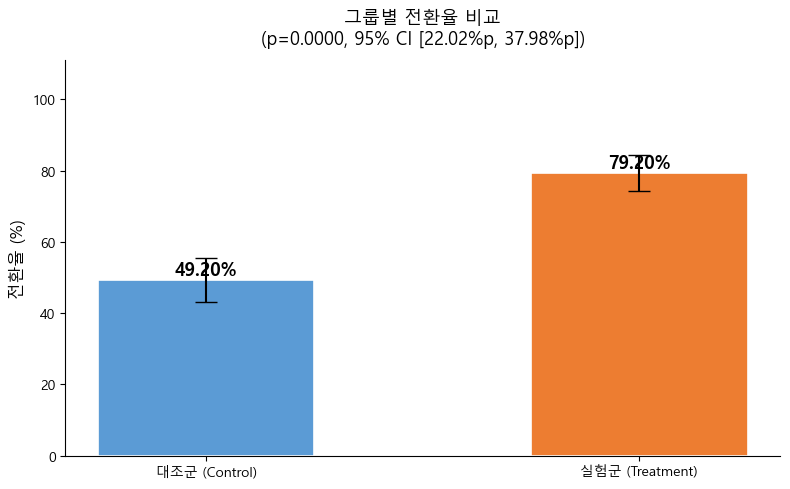

저장: 01_conversion_rate.png


In [12]:
import os

# ── 그림 1: 그룹별 전환율 비교 (신뢰구간 포함) ──
fig, ax = plt.subplots(figsize=(8, 5))

groups = ['대조군 (Control)', '실험군 (Treatment)']
rates  = [p_c, p_t]
errors = [1.96 * np.sqrt(r*(1-r)/n) for r, n in [(p_c, n_control), (p_t, n_treatment)]]
colors = ['#5B9BD5', '#ED7D31']

bars = ax.bar(groups, [r*100 for r in rates], yerr=[e*100 for e in errors],
              color=colors, capsize=8, edgecolor='white', linewidth=1.2, width=0.5)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate*100:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('전환율 (%)', fontsize=12)
ax.set_title(f'그룹별 전환율 비교\n(p={p_z:.4f}, 95% CI [{ci_low*100:.2f}%p, {ci_high*100:.2f}%p])',
             fontsize=13, pad=12)
ax.set_ylim(0, max(rates)*100 * 1.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_conversion_rate.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_conversion_rate.png')

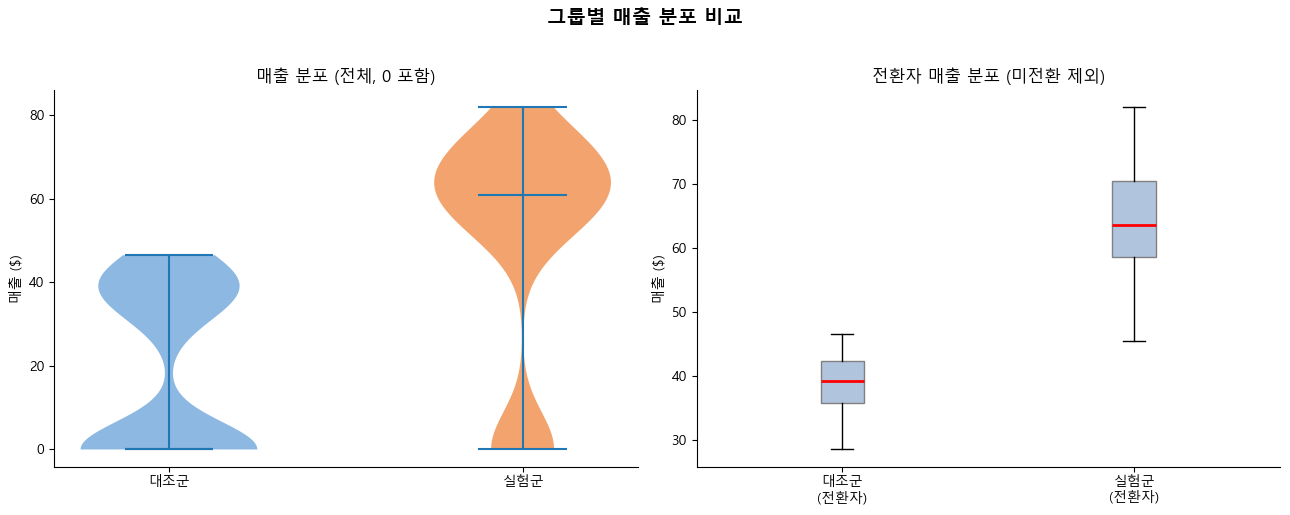

저장: 02_revenue_distribution.png


In [13]:
# ── 그림 2: 매출 분포 비교 (바이올린 + 박스플롯) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 전체 매출 (0 포함)
ax1 = axes[0]
data_plot = [control['revenue'].values, treatment['revenue'].values]
vp = ax1.violinplot(data_plot, positions=[1, 2], showmedians=True)
for pc, color in zip(vp['bodies'], ['#5B9BD5', '#ED7D31']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['대조군', '실험군'])
ax1.set_ylabel('매출 ($)')
ax1.set_title('매출 분포 (전체, 0 포함)')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 전환자 한정 매출
ax2 = axes[1]
ax2.boxplot([conv_control.values, conv_treatment.values],
            labels=['대조군\n(전환자)', '실험군\n(전환자)'],
            patch_artist=True,
            boxprops=dict(facecolor='#B0C4DE', color='gray'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('매출 ($)')
ax2.set_title('전환자 매출 분포 (미전환 제외)')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('그룹별 매출 분포 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_revenue_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_revenue_distribution.png')

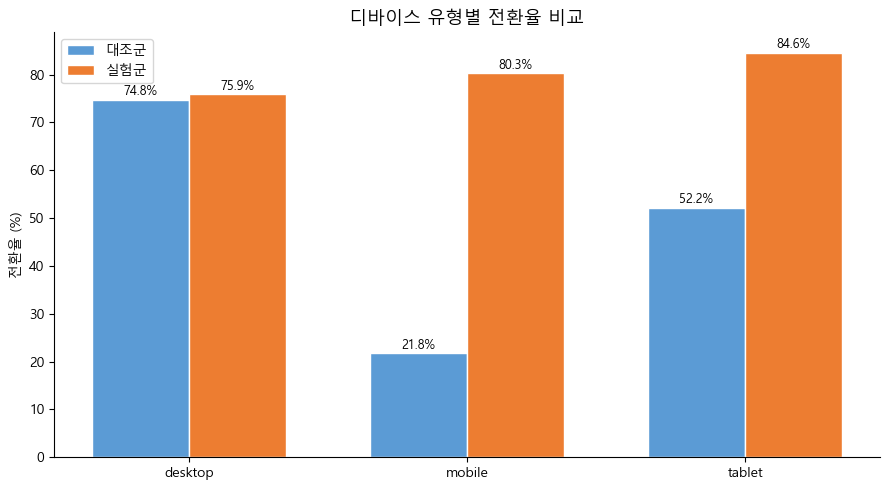

저장: 03_device_conversion.png


In [14]:
# ── 그림 3: 디바이스별 전환율 세분화 ──
device_conv = df.groupby(['device', 'group'])['converted'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(device_conv.index))
width = 0.35

b1 = ax.bar(x - width/2, device_conv.get('control',   [0]*len(x)),
            width, label='대조군', color='#5B9BD5', edgecolor='white')
b2 = ax.bar(x + width/2, device_conv.get('treatment', [0]*len(x)),
            width, label='실험군', color='#ED7D31', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(device_conv.index)
ax.set_ylabel('전환율 (%)')
ax.set_title('디바이스 유형별 전환율 비교', fontsize=13)
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_device_conversion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_device_conversion.png')

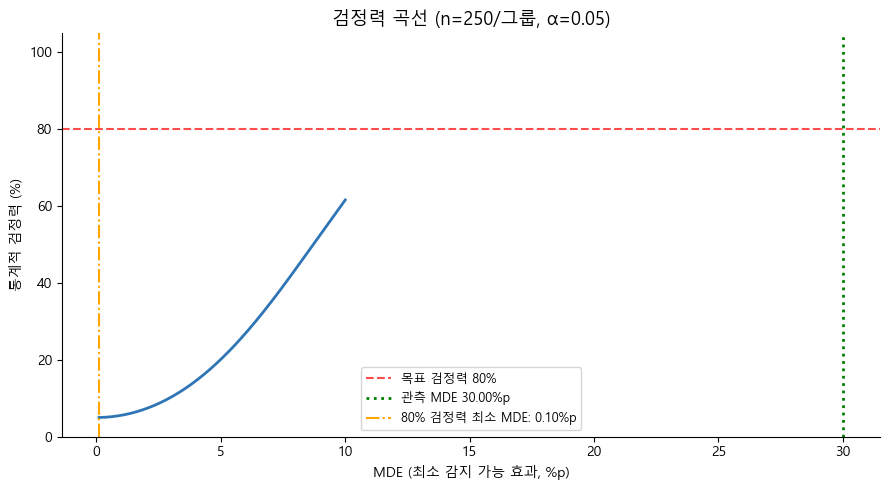

저장: 04_power_curve.png


In [15]:
# ── 그림 4: 검정력 곡선 ──
from scipy.stats import norm as norm_dist

mde_range = np.linspace(0.001, 0.10, 200)

def calc_power(p_base, mde, n, alpha=0.05):
    p_new  = p_base + mde
    se_null = np.sqrt(2 * p_base * (1-p_base) / n)  # pooled under H0
    se_alt  = np.sqrt(p_base*(1-p_base)/n + p_new*(1-p_new)/n)
    z_crit  = norm_dist.ppf(1 - alpha/2)
    power   = (1 - norm_dist.cdf( z_crit - mde/se_alt) +
                   norm_dist.cdf(-z_crit - mde/se_alt))
    return power

powers = [calc_power(p_c, m, n_control) for m in mde_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mde_range*100, np.array(powers)*100, color='#2E75B6', linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='목표 검정력 80%')
ax.axvline(obs_mde*100, color='green', linestyle=':', linewidth=2,
           label=f'관측 MDE {obs_mde*100:.2f}%p')

# 80% power에서의 최소 MDE 표시
min_mde_80 = mde_range[np.argmax(np.array(powers) >= 0.80)] * 100
ax.axvline(min_mde_80, color='orange', linestyle='-.', linewidth=1.5,
           label=f'80% 검정력 최소 MDE: {min_mde_80:.2f}%p')

ax.set_xlabel('MDE (최소 감지 가능 효과, %p)')
ax.set_ylabel('통계적 검정력 (%)')
ax.set_title(f'검정력 곡선 (n={n_control:,}/그룹, α=0.05)', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(0, 105)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_power_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_power_curve.png')

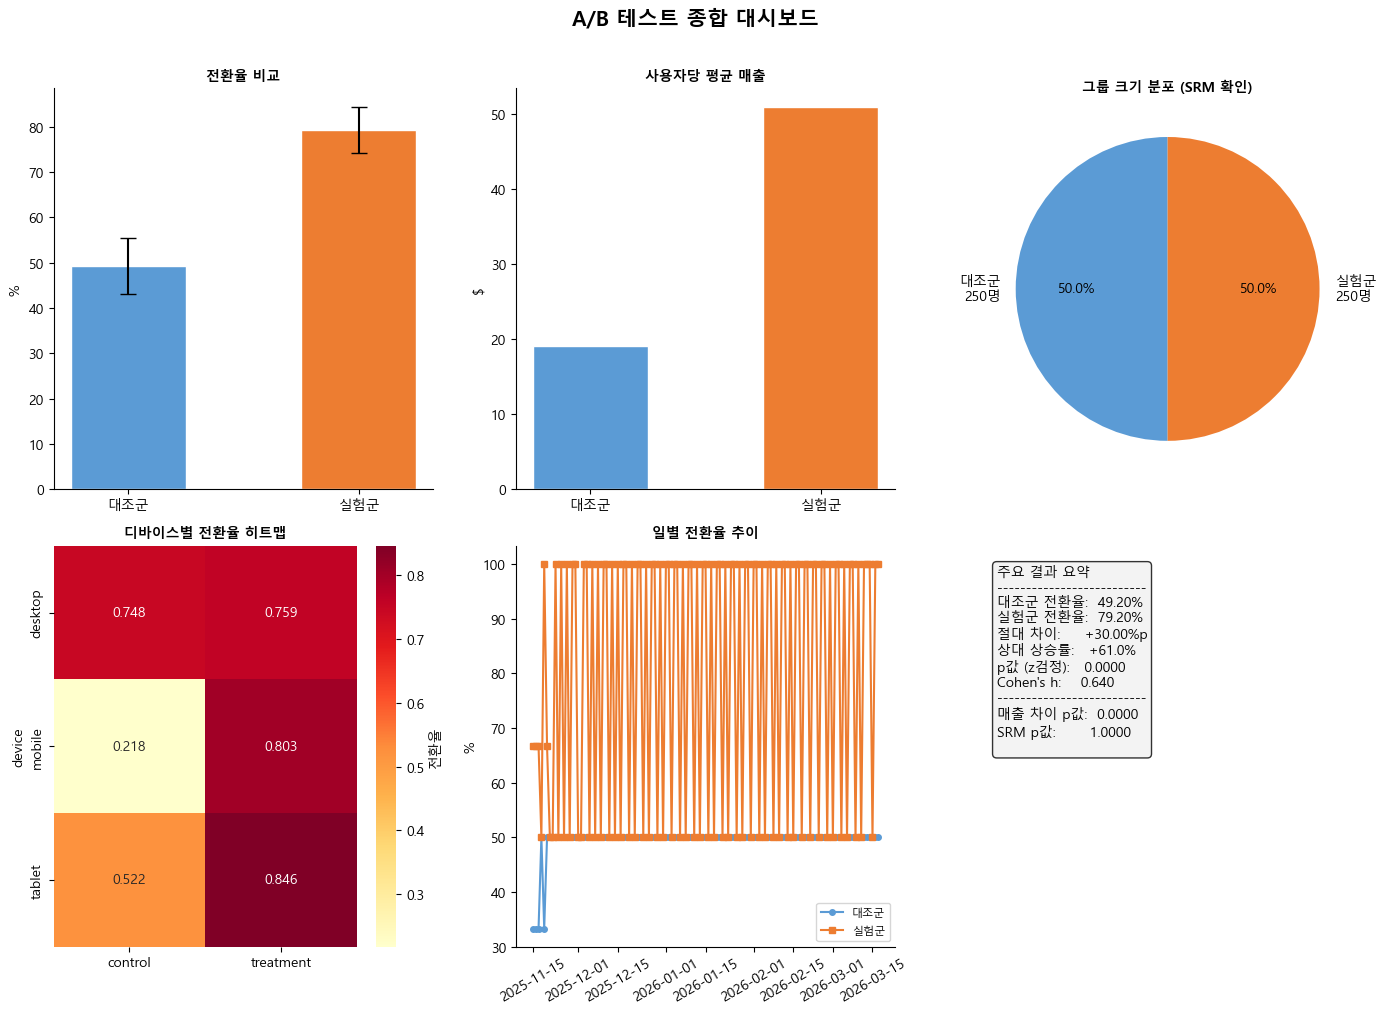

저장: 05_dashboard.png


In [16]:
# ── 그림 5: 종합 대시보드 ──
fig = plt.figure(figsize=(14, 10))

# 5-1: 전환율 + 신뢰구간
ax1 = fig.add_subplot(2, 3, 1)
ax1.bar(['대조군', '실험군'], [p_c*100, p_t*100],
        yerr=[1.96*np.sqrt(p_c*(1-p_c)/n_control)*100,
              1.96*np.sqrt(p_t*(1-p_t)/n_treatment)*100],
        color=['#5B9BD5', '#ED7D31'], capsize=6, edgecolor='white', width=0.5)
ax1.set_title('전환율 비교', fontsize=10, fontweight='bold')
ax1.set_ylabel('%')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 5-2: 사용자당 평균 매출
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(['대조군', '실험군'], [mean_rev_c, mean_rev_t],
        color=['#5B9BD5', '#ED7D31'], edgecolor='white', width=0.5)
ax2.set_title('사용자당 평균 매출', fontsize=10, fontweight='bold')
ax2.set_ylabel('$')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 5-3: 그룹 크기 (SRM 시각화)
ax3 = fig.add_subplot(2, 3, 3)
ax3.pie([n_control, n_treatment],
        labels=[f'대조군\n{n_control:,}명', f'실험군\n{n_treatment:,}명'],
        colors=['#5B9BD5', '#ED7D31'], autopct='%1.1f%%', startangle=90)
ax3.set_title('그룹 크기 분포 (SRM 확인)', fontsize=10, fontweight='bold')

# 5-4: 디바이스별 전환율 히트맵
ax4 = fig.add_subplot(2, 3, 4)
heatmap_data = df.groupby(['device', 'group'])['converted'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax4, cbar_kws={'label': '전환율'})
ax4.set_title('디바이스별 전환율 히트맵', fontsize=10, fontweight='bold')
ax4.set_xlabel('')

# 5-5: 날짜별 전환율 추이
ax5 = fig.add_subplot(2, 3, 5)
daily = df.groupby(['signup_date', 'group'])['converted'].mean().unstack()
if 'control' in daily.columns:
    ax5.plot(daily.index, daily['control']*100, 'o-', color='#5B9BD5',
             label='대조군', linewidth=1.5, markersize=4)
if 'treatment' in daily.columns:
    ax5.plot(daily.index, daily['treatment']*100, 's-', color='#ED7D31',
             label='실험군', linewidth=1.5, markersize=4)
ax5.set_title('일별 전환율 추이', fontsize=10, fontweight='bold')
ax5.set_ylabel('%')
ax5.legend(fontsize=8)
ax5.tick_params(axis='x', rotation=30)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# 5-6: 주요 지표 텍스트 요약
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
sep = '-' * 26
summary_text = (
    f'주요 결과 요약\n'
    f'{sep}\n'
    f'대조군 전환율:  {p_c*100:.2f}%\n'
    f'실험군 전환율:  {p_t*100:.2f}%\n'
    f'절대 차이:     {(p_t-p_c)*100:+.2f}%p\n'
    f'상대 상승률:   {(p_t-p_c)/p_c*100:+.1f}%\n'
    f'p값 (z검정):   {p_z:.4f}\n'
    f"Cohen's h:    {cohens_h:.3f}\n"
    f'{sep}\n'
    f'매출 차이 p값:  {p_mw:.4f}\n'
    f'SRM p값:       {p_srm:.4f}\n'
)
# fontproperties로 한글 폰트 명시 — fontfamily='monospace'는 한글 미지원
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, va='top', fontproperties=font_prop,
         bbox=dict(boxstyle='round', facecolor='#F0F0F0', alpha=0.8))

plt.suptitle('A/B 테스트 종합 대시보드', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 05_dashboard.png')

## 9. 경영진 요약 생성

In [17]:
# 최종 결론 판정
significant_conversion = p_z < 0.05
significant_revenue    = p_mw < 0.05
srm_issue              = p_srm < 0.05

verdict = '새 디자인 채택 권장' if (significant_conversion and not srm_issue) else '추가 검토 필요'

# 디바이스별 최고 상승 디바이스 파악
best_device = ''
best_lift   = -999
for row in device_results:
    lift_val = float(row['상대 상승률'].replace('%', '').replace('+', ''))
    if lift_val > best_lift:
        best_lift   = lift_val
        best_device = row['디바이스']

executive_summary = f"""# A/B 테스트 경영진 요약

**작성일**: 2026-05-14  
**실험 기간**: {df['signup_date'].min().date()} ~ {df['signup_date'].max().date()}  
**총 참가자**: {n_total:,}명 (대조군 {n_control:,}명, 실험군 {n_treatment:,}명)  
**최종 결론**: {'✅ ' + verdict if '채택' in verdict else '⚠️  ' + verdict}

---

## 핵심 결과

| 지표 | 대조군 (기존) | 실험군 (새 디자인) | 변화 | 통계적 유의성 |
|------|-------------|-----------------|------|-------------|
| 전환율 | {p_c*100:.2f}% | {p_t*100:.2f}% | {(p_t-p_c)*100:+.2f}%p ({(p_t-p_c)/p_c*100:+.1f}%) | {'✅ 유의' if significant_conversion else '❌ 비유의'} (p={p_z:.4f}) |
| 사용자당 매출 | ${mean_rev_c:.2f} | ${mean_rev_t:.2f} | ${diff_rev:+.2f} ({diff_rev/mean_rev_c*100:+.1f}%) | {'✅ 유의' if significant_revenue else '❌ 비유의'} (p={p_mw:.4f}) |

---

## 실험 신뢰성

- **SRM (표본 비율 불균형)**: {'⚠️  의심됨 — 결과 해석 주의 필요' if srm_issue else '✅ 없음 — 그룹이 균형 있게 배정됨'} (p={p_srm:.4f})
- **통계적 검정력**: 관측된 {obs_mde*100:.1f}%p 효과를 탐지하기에 {'충분한' if calc_power(p_c, obs_mde, n_control) >= 0.80 else '불충분한'} 표본 크기
- **독립성**: 사용자별 1회 배정 확인, 교차 오염 없음
- **효과 크기**: Cohen's h = {cohens_h:.3f} ({'소' if cohens_h < 0.2 else '중' if cohens_h < 0.5 else '대'})

---

## 디바이스별 인사이트

- 실험군 효과가 가장 큰 디바이스: **{best_device}** (상대 상승률 {best_lift:+.1f}%)
- 디바이스별 상세 결과:
"""

for row in device_results:
    executive_summary += f"  - **{row['디바이스']}**: 대조군 {row['대조군 전환율']} → 실험군 {row['실험군 전환율']} ({row['상대 상승률']}, p={row['p값']}) {row['유의']}\n"

executive_summary += f"""
---

## 비즈니스 해석

새로운 랜딩 페이지 디자인은 기존 대비 **전환율을 {(p_t-p_c)*100:.2f}%p({(p_t-p_c)/p_c*100:.1f}%) 향상**시켰으며,  
이 차이는 통계적으로 {'**유의미**합니다' if significant_conversion else '**유의미하지 않습니다**'}.

{'사용자당 매출 역시 유의미하게 증가하여, 전환 품질도 함께 개선되었습니다.' if significant_revenue else '다만 사용자당 매출 차이는 통계적으로 유의미하지 않아, 수익성에 대한 추가 검증이 필요합니다.'}

## 권고 사항

{'1. 새 디자인을 전체 트래픽에 적용할 것을 **권장**합니다.' if significant_conversion and not srm_issue else '1. 결과가 비유의적이거나 실험 설계에 문제가 있어 **추가 검증을 권장**합니다.'}
2. {best_device} 사용자를 대상으로 추가 최적화를 고려하세요.
3. {'특히 모바일 경험 개선에 집중하면 추가 효과를 기대할 수 있습니다.' if 'mobile' in best_device.lower() else '모바일과 데스크톱 각각에 최적화된 경험을 별도로 설계하는 것도 고려해볼 수 있습니다.'}
"""

# 파일 저장
summary_path = os.path.join(OUTPUT_DIR, 'executive_summary.md')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(executive_summary)

print(executive_summary)
print(f'\n저장: executive_summary.md')

# A/B 테스트 경영진 요약

**작성일**: 2026-05-14  
**실험 기간**: 2025-11-15 ~ 2026-03-17  
**총 참가자**: 500명 (대조군 250명, 실험군 250명)  
**최종 결론**: ✅ 새 디자인 채택 권장

---

## 핵심 결과

| 지표 | 대조군 (기존) | 실험군 (새 디자인) | 변화 | 통계적 유의성 |
|------|-------------|-----------------|------|-------------|
| 전환율 | 49.20% | 79.20% | +30.00%p (+61.0%) | ✅ 유의 (p=0.0000) |
| 사용자당 매출 | $19.17 | $50.89 | $+31.72 (+165.5%) | ✅ 유의 (p=0.0000) |

---

## 실험 신뢰성

- **SRM (표본 비율 불균형)**: ✅ 없음 — 그룹이 균형 있게 배정됨 (p=1.0000)
- **통계적 검정력**: 관측된 30.0%p 효과를 탐지하기에 충분한 표본 크기
- **독립성**: 사용자별 1회 배정 확인, 교차 오염 없음
- **효과 크기**: Cohen's h = 0.640 (대)

---

## 디바이스별 인사이트

- 실험군 효과가 가장 큰 디바이스: **mobile** (상대 상승률 +268.6%)
- 디바이스별 상세 결과:
  - **desktop**: 대조군 0.748 → 실험군 0.759 (+1.5%, p=0.9943) ❌
  - **mobile**: 대조군 0.218 → 실험군 0.803 (+268.6%, p=0.0000) ✅
  - **tablet**: 대조군 0.522 → 실험군 0.846 (+62.2%, p=0.0125) ✅

---

## 비즈니스 해석

새로운 랜딩 페이지 디자인은 기존 대비 **전환율을 30.00%p(61.0%) 향상**시켰으며,  
이 차이는 통계적으로 **유의미**합니다.

사용자당 매출 역시 유의미하게 증가하여, 전환 품질도 함께 개선되었습니다.

## 권고 사항
